## 1. Import Libraries và Load Data

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [19]:
# Load dữ liệu đã merge và cleaned
df = pd.read_csv('../processed/final_combined_data.csv')
df['time'] = pd.to_datetime(df['time'])

print("="*70)
print("DỮ LIỆU ĐÃ LOAD")
print("="*70)
print(f"Số dòng: {len(df)}")
print(f"Số cột: {len(df.columns)}")
print(f"Khoảng thời gian: {df['time'].min()} đến {df['time'].max()}")

# Thông tin địa lý
LAT = 10.823
LON = 106.6296
YEAR = 2024
LOCATION = "TP.HCM"

print(f"\n📍 Thông tin địa lý:")
print(f"  - Vĩ độ: {LAT}°N")
print(f"  - Kinh độ: {LON}°E")
print(f"  - Địa điểm: {LOCATION}")
print(f"  - Năm: {YEAR}")

DỮ LIỆU ĐÃ LOAD
Số dòng: 366
Số cột: 38
Khoảng thời gian: 2024-01-01 00:00:00 đến 2024-12-31 00:00:00

📍 Thông tin địa lý:
  - Vĩ độ: 10.823°N
  - Kinh độ: 106.6296°E
  - Địa điểm: TP.HCM
  - Năm: 2024


## 2. Lọc Dữ liệu Sau QA (Chỉ giữ dữ liệu không có vấn đề)

In [20]:
print("="*70)

print("CHUẨN BỊ DỮ LIỆU ĐỂ TÍNH THỐNG KÊ")

print("="*70)


# Chọn các cột dữ liệu chính (không phải flag QA)

data_cols = ['time', 'temperature_avg_C', 'precipitation_mm', 'wind_speed_kmh',

             'wind_direction_deg', 'pressure_hPa',

             'pm10_ugm3', 'pm2_5_ugm3', 'uv_index', 'ozone_ugm3', 'co_ugm3', 'co2_ppm']


# Sử dụng TẤT CẢ dữ liệu thay vì lọc theo has_any_quality_issues

# Lý do: Một số cột như wind_direction và co2 bị missing hoàn toàn (100%)

#        nhưng điều này KHÔNG làm mất giá trị của các phép đo khác như

#        nhiệt độ, áp suất, PM2.5, v.v.

# Pandas sẽ tự động xử lý NaN trong các hàm thống kê (mean, sum, etc.)

df_clean = df[data_cols].copy()


print(f"\\n Tổng số dòng dữ liệu: {len(df_clean)}")

print(f"\\n Kiểm tra dữ liệu missing:")

missing_pct = (df_clean.isnull().sum() / len(df_clean) * 100).round(2)

for col in data_cols[1:]:  # Bỏ qua cột 'time'

    if missing_pct[col] > 0:

        print(f"  - {col}: {missing_pct[col]}% missing")


print(f"\\n Đã chọn {len(data_cols)} cột để tính toán thống kê")

print(" Các giá trị NaN sẽ được xử lý tự động trong aggregation")

CHUẨN BỊ DỮ LIỆU ĐỂ TÍNH THỐNG KÊ
\n Tổng số dòng dữ liệu: 366
\n Kiểm tra dữ liệu missing:
  - precipitation_mm: 3.28% missing
  - wind_direction_deg: 100.0% missing
  - co2_ppm: 81.69% missing
\n Đã chọn 12 cột để tính toán thống kê
 Các giá trị NaN sẽ được xử lý tự động trong aggregation


## 3. Định nghĩa Các Chỉ số Thống kê

In [21]:
# Định nghĩa metadata cho các chỉ số thống kê
statistics_metadata = [
    # NHIỆT ĐỘ
    {
        'indicator': 'temp_mean',
        'name': 'Nhiệt độ trung bình',
        'objective': 'Đo xu hướng nhiệt độ trung tâm trong khoảng thời gian',
        'formula': 'mean(temperature_avg_C)',
        'unit': '°C'
    },
    {
        'indicator': 'temp_p50',
        'name': 'Nhiệt độ trung vị (P50)',
        'objective': 'Giá trị nhiệt độ ở vị trí giữa, ít bị ảnh hưởng bởi outlier',
        'formula': 'quantile(temperature_avg_C, 0.50)',
        'unit': '°C'
    },
    {
        'indicator': 'temp_p95',
        'name': 'Nhiệt độ phân vị 95 (P95)',
        'objective': 'Phát hiện các ngày nóng cực đoan (5% ngày nóng nhất)',
        'formula': 'quantile(temperature_avg_C, 0.95)',
        'unit': '°C'
    },
    
    # LƯỢNG MƯA
    {
        'indicator': 'precip_total',
        'name': 'Tổng lượng mưa',
        'objective': 'Đo tổng lượng mưa tích lũy trong khoảng thời gian',
        'formula': 'sum(precipitation_mm)',
        'unit': 'mm'
    },
    {
        'indicator': 'rainy_days',
        'name': 'Số ngày mưa',
        'objective': 'Đếm số ngày có lượng mưa ≥ 1mm',
        'formula': 'count(precipitation_mm >= 1)',
        'unit': 'ngày'
    },
    
    # GIÓ
    {
        'indicator': 'wind_speed_mean',
        'name': 'Tốc độ gió trung bình',
        'objective': 'Đo tốc độ gió điển hình trong khoảng thời gian',
        'formula': 'mean(wind_speed_kmh)',
        'unit': 'km/h'
    },
    
    # ÁP SUẤT
    {
        'indicator': 'pressure_mean',
        'name': 'Áp suất trung bình',
        'objective': 'Đo áp suất khí quyển trung bình',
        'formula': 'mean(pressure_hPa)',
        'unit': 'hPa'
    },
    {
        'indicator': 'pressure_std',
        'name': 'Độ lệch chuẩn áp suất',
        'objective': 'Đo biến động áp suất (độ không ổn định thời tiết)',
        'formula': 'std(pressure_hPa)',
        'unit': 'hPa'
    },
    
    # CHẤT LƯỢNG KHÔNG KHÍ - PM2.5
    {
        'indicator': 'pm2_5_mean',
        'name': 'PM2.5 trung bình',
        'objective': 'Đo nồng độ bụi mịn PM2.5 trung bình',
        'formula': 'mean(pm2_5_ugm3)',
        'unit': 'μg/m³'
    },
    {
        'indicator': 'pm2_5_p95',
        'name': 'PM2.5 phân vị 95',
        'objective': 'Phát hiện các ngày ô nhiễm cao (5% ngày ô nhiễm nhất)',
        'formula': 'quantile(pm2_5_ugm3, 0.95)',
        'unit': 'μg/m³'
    },
    {
        'indicator': 'pm2_5_exceed_days',
        'name': 'Số ngày PM2.5 vượt ngưỡng',
        'objective': 'Đếm số ngày PM2.5 vượt 25 μg/m³ (WHO guideline)',
        'formula': 'count(pm2_5_ugm3 > 25)',
        'unit': 'ngày'
    },
    
    # CHẤT LƯỢNG KHÔNG KHÍ - PM10
    {
        'indicator': 'pm10_mean',
        'name': 'PM10 trung bình',
        'objective': 'Đo nồng độ bụi thô PM10 trung bình',
        'formula': 'mean(pm10_ugm3)',
        'unit': 'μg/m³'
    },
    {
        'indicator': 'pm10_p95',
        'name': 'PM10 phân vị 95',
        'objective': 'Phát hiện các ngày ô nhiễm PM10 cao',
        'formula': 'quantile(pm10_ugm3, 0.95)',
        'unit': 'μg/m³'
    },
    {
        'indicator': 'pm10_exceed_days',
        'name': 'Số ngày PM10 vượt ngưỡng',
        'objective': 'Đếm số ngày PM10 vượt 45 μg/m³ (WHO guideline)',
        'formula': 'count(pm10_ugm3 > 45)',
        'unit': 'ngày'
    },
    
    # UV INDEX
    {
        'indicator': 'uv_max_mean',
        'name': 'UV Index trung bình tối đa',
        'objective': 'Đo mức độ bức xạ UV trung bình trong ngày (đã là daily max)',
        'formula': 'mean(uv_index)',
        'unit': 'index'
    },
    
    # OZONE
    {
        'indicator': 'ozone_mean',
        'name': 'Ozone trung bình',
        'objective': 'Đo nồng độ ozone trung bình',
        'formula': 'mean(ozone_ugm3)',
        'unit': 'μg/m³'
    }
]

# Chuyển thành DataFrame
df_metadata = pd.DataFrame(statistics_metadata)

print("="*70)
print("CÁC CHỈ SỐ THỐNG KÊ ĐƯỢC ĐỊNH NGHĨA")
print("="*70)
print(df_metadata[['indicator', 'name', 'unit']].to_string(index=False))
print(f"\n✓ Tổng số: {len(df_metadata)} chỉ số")

CÁC CHỈ SỐ THỐNG KÊ ĐƯỢC ĐỊNH NGHĨA
        indicator                       name  unit
        temp_mean        Nhiệt độ trung bình    °C
         temp_p50    Nhiệt độ trung vị (P50)    °C
         temp_p95  Nhiệt độ phân vị 95 (P95)    °C
     precip_total             Tổng lượng mưa    mm
       rainy_days                Số ngày mưa  ngày
  wind_speed_mean      Tốc độ gió trung bình  km/h
    pressure_mean         Áp suất trung bình   hPa
     pressure_std      Độ lệch chuẩn áp suất   hPa
       pm2_5_mean           PM2.5 trung bình μg/m³
        pm2_5_p95           PM2.5 phân vị 95 μg/m³
pm2_5_exceed_days  Số ngày PM2.5 vượt ngưỡng  ngày
        pm10_mean            PM10 trung bình μg/m³
         pm10_p95            PM10 phân vị 95 μg/m³
 pm10_exceed_days   Số ngày PM10 vượt ngưỡng  ngày
      uv_max_mean UV Index trung bình tối đa index
       ozone_mean           Ozone trung bình μg/m³

✓ Tổng số: 16 chỉ số


## 4. Thống kê Theo NGÀY (Daily)

In [22]:
print("="*70)
print("THỐNG KÊ THEO NGÀY")
print("="*70)

# Dữ liệu đã ở mức daily, chỉ cần tính các chỉ số
df_daily = df_clean.copy()
df_daily['date'] = df_daily['time'].dt.date

# Tính các chỉ số
daily_stats = pd.DataFrame({
    'date': df_daily['date'],
    
    # Nhiệt độ (đã là trung bình ngày từ source)
    'temp_mean': df_daily['temperature_avg_C'],
    
    # Lượng mưa
    'precip_total': df_daily['precipitation_mm'],
    'is_rainy_day': (df_daily['precipitation_mm'] >= 1).astype(int),
    
    # Gió
    'wind_speed_mean': df_daily['wind_speed_kmh'],
    'wind_direction': df_daily['wind_direction_deg'],
    
    # Áp suất
    'pressure_mean': df_daily['pressure_hPa'],
    
    # Chất lượng không khí
    'pm2_5_mean': df_daily['pm2_5_ugm3'],
    'pm2_5_exceed': (df_daily['pm2_5_ugm3'] > 25).astype(int),
    'pm10_mean': df_daily['pm10_ugm3'],
    'pm10_exceed': (df_daily['pm10_ugm3'] > 45).astype(int),
    
    # UV & Ozone
    'uv_max': df_daily['uv_index'],
    'ozone_mean': df_daily['ozone_ugm3'],
    'co_mean': df_daily['co_ugm3']
})

print(f"\n📊 Số ngày có dữ liệu: {len(daily_stats)}")
print(f"\n🔍 Preview 5 ngày đầu:")
print(daily_stats.head())

# Lưu file
output_daily = f'../processed/daily_weather_aqi_{LAT}_{LON}_{YEAR}.csv'
daily_stats.to_csv(output_daily, index=False)
print(f"\n✓ Đã lưu: {output_daily}")

THỐNG KÊ THEO NGÀY

📊 Số ngày có dữ liệu: 366

🔍 Preview 5 ngày đầu:
         date  temp_mean  precip_total  is_rainy_day  wind_speed_mean  \
0  2024-01-01       28.2           0.0             0              6.2   
1  2024-01-02       28.6           0.0             0              6.3   
2  2024-01-03       28.6           0.0             0              7.1   
3  2024-01-04       28.2           0.0             0              6.8   
4  2024-01-05       27.7           0.0             0              5.1   

   wind_direction  pressure_mean  pm2_5_mean  pm2_5_exceed  pm10_mean  \
0             NaN         1011.3       39.50             1      59.04   
1             NaN         1010.9       39.01             1      58.75   
2             NaN         1010.9       29.48             1      44.80   
3             NaN         1011.4       27.40             1      42.05   
4             NaN         1012.2       28.22             1      43.02   

   pm10_exceed  uv_max  ozone_mean  co_mean  
0      

## 5. Thống kê Theo TUẦN (Weekly)

In [23]:
print("="*70)
print("THỐNG KÊ THEO TUẦN")
print("="*70)

# Set time as index for resampling
df_clean_indexed = df_clean.set_index('time')

# Resample theo tuần (W-SUN: tuần kết thúc vào Chủ nhật)
weekly_stats = pd.DataFrame({
    'week_start': df_clean_indexed.resample('W-SUN').first().index,
    'week_number': df_clean_indexed.resample('W-SUN').first().index.isocalendar().week,
    
    # Nhiệt độ
    'temp_mean': df_clean_indexed['temperature_avg_C'].resample('W-SUN').mean(),
    'temp_p50': df_clean_indexed['temperature_avg_C'].resample('W-SUN').quantile(0.50),
    'temp_p95': df_clean_indexed['temperature_avg_C'].resample('W-SUN').quantile(0.95),
    'temp_min': df_clean_indexed['temperature_avg_C'].resample('W-SUN').min(),
    'temp_max': df_clean_indexed['temperature_avg_C'].resample('W-SUN').max(),
    
    # Lượng mưa
    'precip_total': df_clean_indexed['precipitation_mm'].resample('W-SUN').sum(),
    'rainy_days': (df_clean_indexed['precipitation_mm'] >= 1).resample('W-SUN').sum(),
    
    # Gió
    'wind_speed_mean': df_clean_indexed['wind_speed_kmh'].resample('W-SUN').mean(),
    'wind_speed_max': df_clean_indexed['wind_speed_kmh'].resample('W-SUN').max(),
    
    # Áp suất
    'pressure_mean': df_clean_indexed['pressure_hPa'].resample('W-SUN').mean(),
    'pressure_std': df_clean_indexed['pressure_hPa'].resample('W-SUN').std(),
    
    # PM2.5
    'pm2_5_mean': df_clean_indexed['pm2_5_ugm3'].resample('W-SUN').mean(),
    'pm2_5_p95': df_clean_indexed['pm2_5_ugm3'].resample('W-SUN').quantile(0.95),
    'pm2_5_exceed_days': (df_clean_indexed['pm2_5_ugm3'] > 25).resample('W-SUN').sum(),
    
    # PM10
    'pm10_mean': df_clean_indexed['pm10_ugm3'].resample('W-SUN').mean(),
    'pm10_p95': df_clean_indexed['pm10_ugm3'].resample('W-SUN').quantile(0.95),
    'pm10_exceed_days': (df_clean_indexed['pm10_ugm3'] > 45).resample('W-SUN').sum(),
    
    # UV & Ozone
    'uv_max_mean': df_clean_indexed['uv_index'].resample('W-SUN').mean(),
    'ozone_mean': df_clean_indexed['ozone_ugm3'].resample('W-SUN').mean(),
    
    # Số ngày có dữ liệu
    'data_days': df_clean_indexed['temperature_avg_C'].resample('W-SUN').count()
})

weekly_stats = weekly_stats.reset_index(drop=True)
weekly_stats = weekly_stats.round(2)

print(f"\n📊 Số tuần có dữ liệu: {len(weekly_stats)}")
print(f"\n🔍 Preview 3 tuần đầu:")
print(weekly_stats.head(3))

# Lưu file
output_weekly = f'../processed/weekly_weather_aqi_{LAT}_{LON}_{YEAR}.csv'
weekly_stats.to_csv(output_weekly, index=False)
print(f"\n✓ Đã lưu: {output_weekly}")

THỐNG KÊ THEO TUẦN

📊 Số tuần có dữ liệu: 53

🔍 Preview 3 tuần đầu:
  week_start  week_number  temp_mean  temp_p50  temp_p95  temp_min  temp_max  \
0 2024-01-07            1      28.40      28.6     28.77      27.7      28.8   
1 2024-01-14            2      28.16      28.5     29.15      27.1      29.3   
2 2024-01-21            3      28.36      28.2     29.00      27.8      29.0   

   precip_total  rainy_days  wind_speed_mean  wind_speed_max  pressure_mean  \
0           0.3           0             6.36             7.1        1011.51   
1           0.0           0             6.79             9.0        1011.34   
2           0.0           0             7.39             9.2        1011.34   

   pressure_std  pm2_5_mean  pm2_5_p95  pm2_5_exceed_days  pm10_mean  \
0          0.55       31.80      39.35                  6      48.38   
1          0.53       28.23      37.24                  4      43.42   
2          0.59       23.67      31.14                  2      36.30   

   pm

## 6. Thống kê Theo THÁNG (Monthly)

In [24]:
print("="*70)
print("THỐNG KÊ THEO THÁNG")
print("="*70)

# Resample theo tháng
monthly_stats = pd.DataFrame({
    'month': df_clean_indexed.resample('MS').first().index.month,
    'month_name': df_clean_indexed.resample('MS').first().index.strftime('%B'),
    'year': df_clean_indexed.resample('MS').first().index.year,
    
    # Nhiệt độ
    'temp_mean': df_clean_indexed['temperature_avg_C'].resample('MS').mean(),
    'temp_p50': df_clean_indexed['temperature_avg_C'].resample('MS').quantile(0.50),
    'temp_p95': df_clean_indexed['temperature_avg_C'].resample('MS').quantile(0.95),
    'temp_min': df_clean_indexed['temperature_avg_C'].resample('MS').min(),
    'temp_max': df_clean_indexed['temperature_avg_C'].resample('MS').max(),
    
    # Lượng mưa
    'precip_total': df_clean_indexed['precipitation_mm'].resample('MS').sum(),
    'rainy_days': (df_clean_indexed['precipitation_mm'] >= 1).resample('MS').sum(),
    'precip_mean_per_rainy_day': df_clean_indexed[df_clean_indexed['precipitation_mm'] >= 1]['precipitation_mm'].resample('MS').mean(),
    
    # Gió
    'wind_speed_mean': df_clean_indexed['wind_speed_kmh'].resample('MS').mean(),
    'wind_speed_max': df_clean_indexed['wind_speed_kmh'].resample('MS').max(),
    
    # Áp suất
    'pressure_mean': df_clean_indexed['pressure_hPa'].resample('MS').mean(),
    'pressure_std': df_clean_indexed['pressure_hPa'].resample('MS').std(),
    'pressure_min': df_clean_indexed['pressure_hPa'].resample('MS').min(),
    'pressure_max': df_clean_indexed['pressure_hPa'].resample('MS').max(),
    
    # PM2.5
    'pm2_5_mean': df_clean_indexed['pm2_5_ugm3'].resample('MS').mean(),
    'pm2_5_p50': df_clean_indexed['pm2_5_ugm3'].resample('MS').quantile(0.50),
    'pm2_5_p95': df_clean_indexed['pm2_5_ugm3'].resample('MS').quantile(0.95),
    'pm2_5_exceed_days': (df_clean_indexed['pm2_5_ugm3'] > 25).resample('MS').sum(),
    
    # PM10
    'pm10_mean': df_clean_indexed['pm10_ugm3'].resample('MS').mean(),
    'pm10_p50': df_clean_indexed['pm10_ugm3'].resample('MS').quantile(0.50),
    'pm10_p95': df_clean_indexed['pm10_ugm3'].resample('MS').quantile(0.95),
    'pm10_exceed_days': (df_clean_indexed['pm10_ugm3'] > 45).resample('MS').sum(),
    
    # UV & Ozone
    'uv_max_mean': df_clean_indexed['uv_index'].resample('MS').mean(),
    'uv_max_p95': df_clean_indexed['uv_index'].resample('MS').quantile(0.95),
    'ozone_mean': df_clean_indexed['ozone_ugm3'].resample('MS').mean(),
    'co_mean': df_clean_indexed['co_ugm3'].resample('MS').mean(),
    
    # Số ngày có dữ liệu
    'data_days': df_clean_indexed['temperature_avg_C'].resample('MS').count()
})

monthly_stats = monthly_stats.reset_index(drop=True)
monthly_stats = monthly_stats.round(2)

print(f"\n📊 Số tháng có dữ liệu: {len(monthly_stats)}")
print(f"\n🔍 Preview tất cả các tháng:")
print(monthly_stats[['month', 'month_name', 'temp_mean', 'precip_total', 'rainy_days', 
                      'pm2_5_mean', 'pm10_mean', 'data_days']])

# Lưu file
output_monthly = f'../processed/monthly_weather_aqi_{LAT}_{LON}_{YEAR}.csv'
monthly_stats.to_csv(output_monthly, index=False)
print(f"\n✓ Đã lưu: {output_monthly}")

THỐNG KÊ THEO THÁNG

📊 Số tháng có dữ liệu: 12

🔍 Preview tất cả các tháng:
    month month_name  temp_mean  precip_total  rainy_days  pm2_5_mean  \
0       1    January      28.52           0.3           0       24.60   
1       2   February      29.33           1.4           1       14.06   
2       3      March      30.05           1.5           0       16.40   
3       4      April      31.62           7.6           2       12.46   
4       5        May      31.00         213.8          23       20.26   
5       6       June      29.70         203.7          24       26.54   
6       7       July      28.32         375.9          30       24.37   
7       8     August      29.19         139.6          22       25.79   
8       9  September      28.01         342.9          25       19.52   
9      10    October      27.89         340.0          27       27.21   
10     11   November      28.47          98.2          15       30.45   
11     12   December      27.15          79.5   

## 7. Tính Chỉ số Chuẩn hóa (Index = 100) Theo Tháng

In [25]:
print("="*70)
print("TÍNH CHỈ SỐ CHUẨN HÓA (INDEX = 100)")
print("="*70)

# Tính index chuẩn hóa (base = 100 cho tháng đầu tiên hoặc trung bình)
# Công thức: Index = (Giá trị hiện tại / Giá trị gốc) * 100

def calculate_index(series, base='mean'):
    """Tính index chuẩn hóa với base = 100"""
    if base == 'mean':
        base_value = series.mean()
    elif base == 'first':
        base_value = series.iloc[0]
    else:
        base_value = base
    
    return (series / base_value * 100).round(2)

# Tính index cho các chỉ số chính
monthly_index = monthly_stats[['month', 'month_name']].copy()
monthly_index['temp_index'] = calculate_index(monthly_stats['temp_mean'], base='mean')
monthly_index['precip_index'] = calculate_index(monthly_stats['precip_total'], base='mean')
monthly_index['wind_index'] = calculate_index(monthly_stats['wind_speed_mean'], base='mean')
monthly_index['pressure_index'] = calculate_index(monthly_stats['pressure_mean'], base='mean')
monthly_index['pm2_5_index'] = calculate_index(monthly_stats['pm2_5_mean'], base='mean')
monthly_index['pm10_index'] = calculate_index(monthly_stats['pm10_mean'], base='mean')
monthly_index['uv_index'] = calculate_index(monthly_stats['uv_max_mean'], base='mean')

print("\n📊 Chỉ số chuẩn hóa theo tháng (Base = 100 là trung bình cả năm):")
print(monthly_index)

# Lưu file
output_index = f'../processed/monthly_normalized_index_{LAT}_{LON}_{YEAR}.csv'
monthly_index.to_csv(output_index, index=False)
print(f"\n✓ Đã lưu: {output_index}")

print("\n💡 Giải thích:")
print("  - Index = 100: Bằng trung bình cả năm")
print("  - Index > 100: Cao hơn trung bình")
print("  - Index < 100: Thấp hơn trung bình")

TÍNH CHỈ SỐ CHUẨN HÓA (INDEX = 100)

📊 Chỉ số chuẩn hóa theo tháng (Base = 100 là trung bình cả năm):
    month month_name  temp_index  precip_index  wind_index  pressure_index  \
0       1    January       97.99          0.20       69.85          100.31   
1       2   February      100.78          0.93      108.19          100.36   
2       3      March      103.25          1.00      121.58          100.20   
3       4      April      108.64          5.05      119.48           99.93   
4       5        May      106.51        142.19       96.17           99.87   
5       6       June      102.05        135.47      106.19           99.88   
6       7       July       97.31        249.99      128.86           99.80   
7       8     August      100.29         92.84      105.46           99.92   
8       9  September       96.24        228.04      112.10           99.76   
9      10    October       95.83        226.11       79.32           99.94   
10     11   November       97.82        

## 8. Phân tích Hướng Gió (Wind Rose)

In [26]:
print("="*70)
print("PHÂN TÍCH HƯỚNG GIÓ (WIND ROSE)")
print("="*70)

# Lọc dữ liệu có wind_direction (không phải NaN)
df_wind = df_clean[df_clean['wind_direction_deg'].notna()].copy()

if len(df_wind) > 0:
    # Phân loại hướng gió theo 8 hướng chính
    def categorize_wind_direction(degree):
        if pd.isna(degree):
            return 'Unknown'
        degree = degree % 360
        directions = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
        idx = int((degree + 22.5) / 45) % 8
        return directions[idx]
    
    df_wind['wind_direction_cat'] = df_wind['wind_direction_deg'].apply(categorize_wind_direction)
    
    # Thống kê theo tháng
    df_wind['month'] = pd.to_datetime(df_wind['time']).dt.month
    
    wind_rose_monthly = df_wind.groupby(['month', 'wind_direction_cat']).size().unstack(fill_value=0)
    wind_rose_monthly_pct = (wind_rose_monthly.T / wind_rose_monthly.sum(axis=1) * 100).T.round(2)
    
    print(f"\n📊 Tần suất hướng gió theo tháng (%, dựa trên {len(df_wind)} ngày có dữ liệu):")
    print(wind_rose_monthly_pct)
    
    # Lưu file
    output_wind = f'../processed/wind_rose_monthly_{LAT}_{LON}_{YEAR}.csv'
    wind_rose_monthly_pct.to_csv(output_wind)
    print(f"\n✓ Đã lưu: {output_wind}")
else:
    print("\n⚠️ Không có dữ liệu hướng gió (wind_direction_deg toàn bộ là NaN)")

PHÂN TÍCH HƯỚNG GIÓ (WIND ROSE)

⚠️ Không có dữ liệu hướng gió (wind_direction_deg toàn bộ là NaN)


## 9. Tạo Bảng Tóm tắt Metadata Chỉ số

In [27]:
import os

print("="*70)
print("LƯU BẢNG METADATA CHỈ SỐ")
print("="*70)

# Tạo thư mục reports nếu chưa có
os.makedirs('../reports', exist_ok=True)

# Lưu metadata
output_metadata = '../reports/statistics_metadata.csv'
df_metadata.to_csv(output_metadata, index=False)

print("\n📄 Bảng metadata các chỉ số thống kê:")
print(df_metadata.to_string(index=False))
print(f"\n✓ Đã lưu: {output_metadata}")

LƯU BẢNG METADATA CHỈ SỐ

📄 Bảng metadata các chỉ số thống kê:
        indicator                       name                                                   objective                           formula  unit
        temp_mean        Nhiệt độ trung bình       Đo xu hướng nhiệt độ trung tâm trong khoảng thời gian           mean(temperature_avg_C)    °C
         temp_p50    Nhiệt độ trung vị (P50) Giá trị nhiệt độ ở vị trí giữa, ít bị ảnh hưởng bởi outlier quantile(temperature_avg_C, 0.50)    °C
         temp_p95  Nhiệt độ phân vị 95 (P95)        Phát hiện các ngày nóng cực đoan (5% ngày nóng nhất) quantile(temperature_avg_C, 0.95)    °C
     precip_total             Tổng lượng mưa           Đo tổng lượng mưa tích lũy trong khoảng thời gian             sum(precipitation_mm)    mm
       rainy_days                Số ngày mưa                              Đếm số ngày có lượng mưa ≥ 1mm      count(precipitation_mm >= 1)  ngày
  wind_speed_mean      Tốc độ gió trung bình              Đo tốc độ

## 10. Tạo Báo cáo Tổng hợp

In [28]:
print("="*70)
print("BÁO CÁO TỔNG HỢP THỐNG KÊ")
print("="*70)

# Tạo báo cáo summary
summary_report = pd.DataFrame({
    'Metric': [
        'Vị trí',
        'Vĩ độ',
        'Kinh độ',
        'Năm',
        'Tổng số ngày trong dữ liệu gốc',
        'Số ngày sau QA (clean)',
        'Tỷ lệ dữ liệu clean',
        'Số tuần',
        'Số tháng',
        'Nhiệt độ trung bình năm',
        'Tổng lượng mưa năm',
        'Số ngày mưa năm',
        'PM2.5 trung bình năm',
        'PM10 trung bình năm',
        'Số ngày PM2.5 vượt ngưỡng',
        'Số ngày PM10 vượt ngưỡng',
        'UV Index trung bình năm'
    ],
    'Value': [
        LOCATION,
        f"{LAT}°N",
        f"{LON}°E",
        YEAR,
        len(df),
        len(df_clean),
        f"{len(df_clean)/len(df)*100:.2f}%",
        len(weekly_stats),
        len(monthly_stats),
        f"{df_clean['temperature_avg_C'].mean():.2f} °C",
        f"{df_clean['precipitation_mm'].sum():.2f} mm",
        (df_clean['precipitation_mm'] >= 1).sum(),
        f"{df_clean['pm2_5_ugm3'].mean():.2f} μg/m³",
        f"{df_clean['pm10_ugm3'].mean():.2f} μg/m³",
        (df_clean['pm2_5_ugm3'] > 25).sum(),
        (df_clean['pm10_ugm3'] > 45).sum(),
        f"{df_clean['uv_index'].mean():.2f}"
    ]
})

print("\n📊 Tóm tắt thống kê:")
print(summary_report.to_string(index=False))

# Lưu báo cáo
output_summary = '../reports/statistics_summary.csv'
summary_report.to_csv(output_summary, index=False)
print(f"\n✓ Đã lưu: {output_summary}")

BÁO CÁO TỔNG HỢP THỐNG KÊ

📊 Tóm tắt thống kê:
                        Metric       Value
                        Vị trí      TP.HCM
                         Vĩ độ    10.823°N
                       Kinh độ  106.6296°E
                           Năm        2024
Tổng số ngày trong dữ liệu gốc         366
        Số ngày sau QA (clean)         366
           Tỷ lệ dữ liệu clean     100.00%
                       Số tuần          53
                      Số tháng          12
       Nhiệt độ trung bình năm    29.10 °C
            Tổng lượng mưa năm  1804.40 mm
               Số ngày mưa năm         179
          PM2.5 trung bình năm 22.67 μg/m³
           PM10 trung bình năm 32.32 μg/m³
     Số ngày PM2.5 vượt ngưỡng         132
      Số ngày PM10 vượt ngưỡng          55
       UV Index trung bình năm        8.83

✓ Đã lưu: ../reports/statistics_summary.csv


## 11. Visualization - Biểu đồ So sánh Theo Tháng

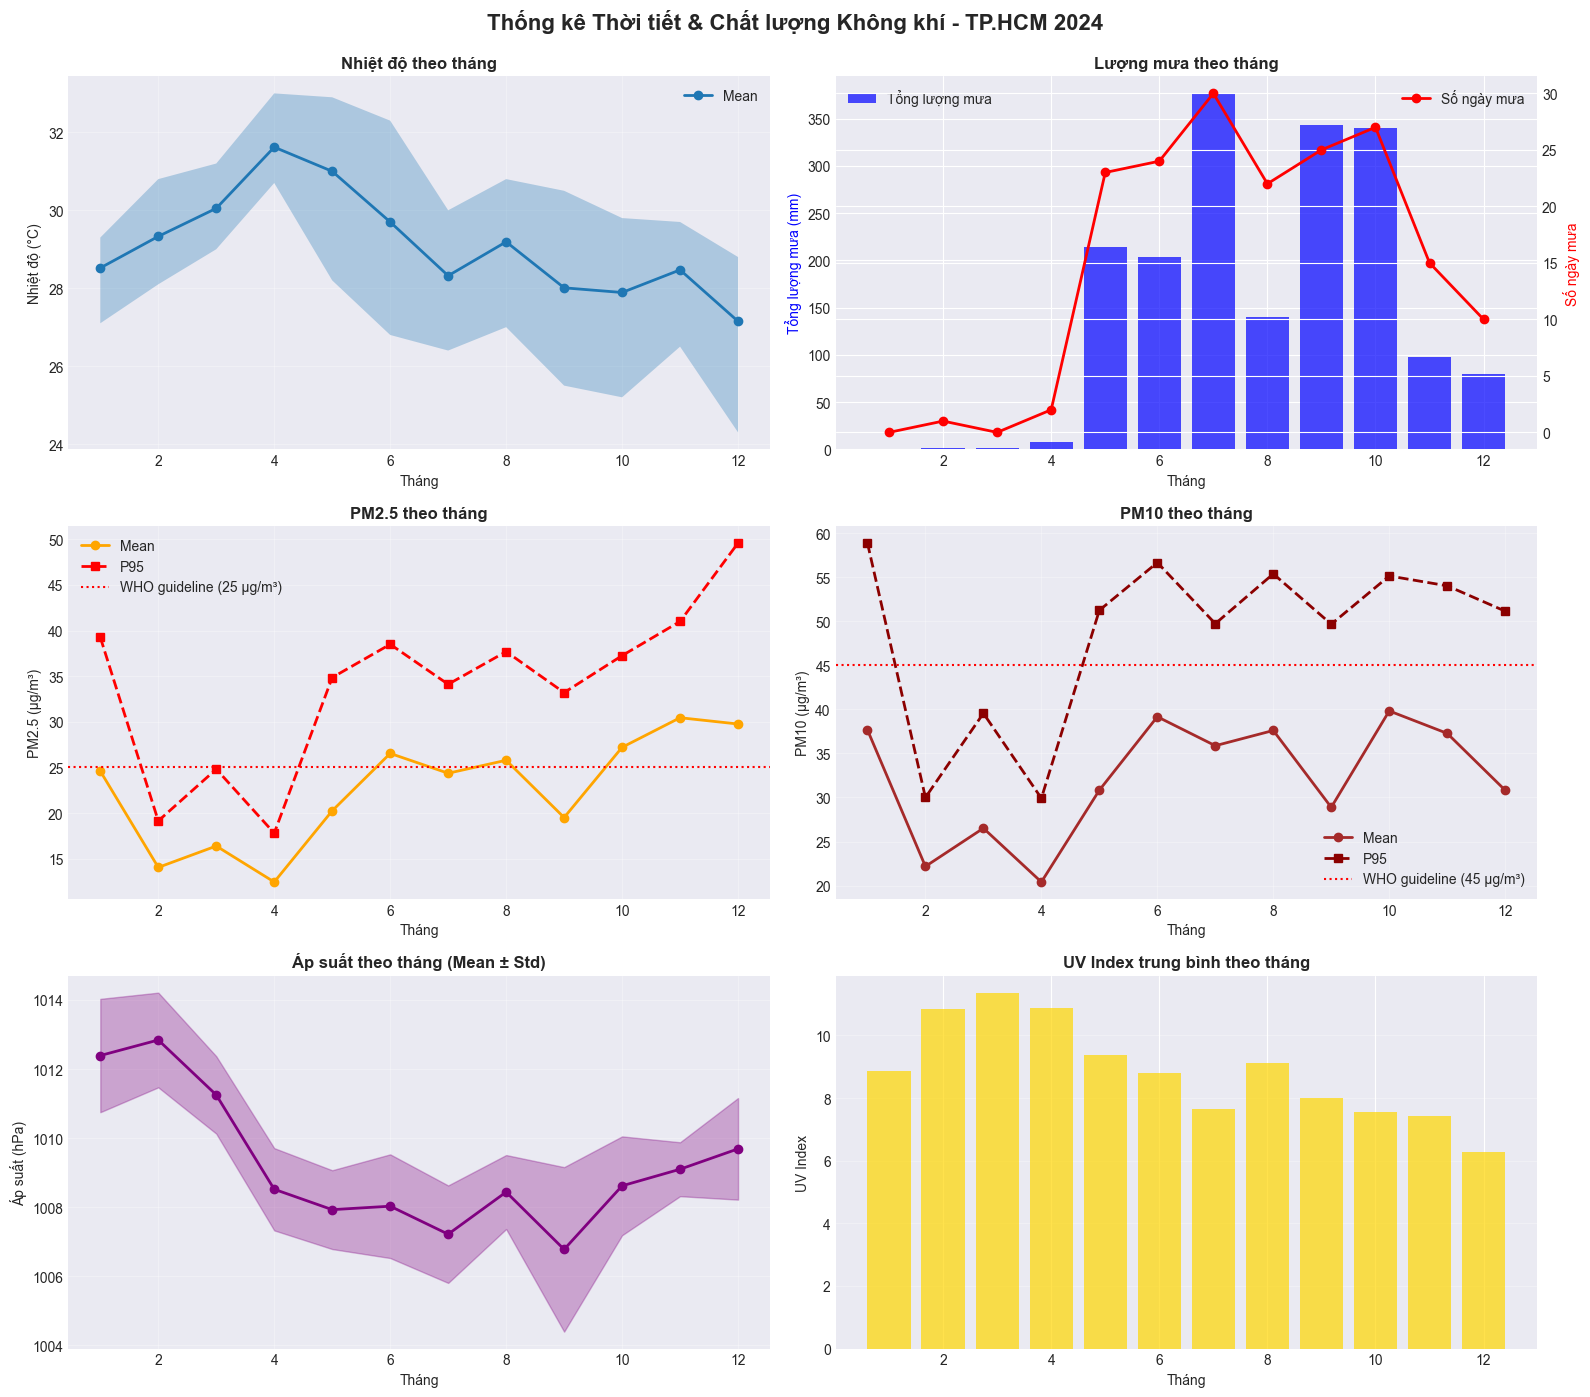


✓ Đã lưu visualization tại: ../reports/monthly_statistics_visualization.pdf


In [29]:
# Tạo biểu đồ so sánh các chỉ số theo tháng
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# 1. Nhiệt độ
axes[0, 0].plot(monthly_stats['month'], monthly_stats['temp_mean'], marker='o', linewidth=2, label='Mean')
axes[0, 0].fill_between(monthly_stats['month'], monthly_stats['temp_min'], monthly_stats['temp_max'], alpha=0.3)
axes[0, 0].set_title('Nhiệt độ theo tháng', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Tháng')
axes[0, 0].set_ylabel('Nhiệt độ (°C)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# 2. Lượng mưa
ax2_twin = axes[0, 1].twinx()
axes[0, 1].bar(monthly_stats['month'], monthly_stats['precip_total'], alpha=0.7, color='blue', label='Tổng lượng mưa')
ax2_twin.plot(monthly_stats['month'], monthly_stats['rainy_days'], marker='o', color='red', linewidth=2, label='Số ngày mưa')
axes[0, 1].set_title('Lượng mưa theo tháng', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Tháng')
axes[0, 1].set_ylabel('Tổng lượng mưa (mm)', color='blue')
ax2_twin.set_ylabel('Số ngày mưa', color='red')
axes[0, 1].legend(loc='upper left')
ax2_twin.legend(loc='upper right')

# 3. PM2.5
axes[1, 0].plot(monthly_stats['month'], monthly_stats['pm2_5_mean'], marker='o', linewidth=2, color='orange', label='Mean')
axes[1, 0].plot(monthly_stats['month'], monthly_stats['pm2_5_p95'], marker='s', linewidth=2, color='red', linestyle='--', label='P95')
axes[1, 0].axhline(y=25, color='red', linestyle=':', label='WHO guideline (25 μg/m³)')
axes[1, 0].set_title('PM2.5 theo tháng', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Tháng')
axes[1, 0].set_ylabel('PM2.5 (μg/m³)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# 4. PM10
axes[1, 1].plot(monthly_stats['month'], monthly_stats['pm10_mean'], marker='o', linewidth=2, color='brown', label='Mean')
axes[1, 1].plot(monthly_stats['month'], monthly_stats['pm10_p95'], marker='s', linewidth=2, color='darkred', linestyle='--', label='P95')
axes[1, 1].axhline(y=45, color='red', linestyle=':', label='WHO guideline (45 μg/m³)')
axes[1, 1].set_title('PM10 theo tháng', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Tháng')
axes[1, 1].set_ylabel('PM10 (μg/m³)')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

# 5. Áp suất
axes[2, 0].plot(monthly_stats['month'], monthly_stats['pressure_mean'], marker='o', linewidth=2, color='purple')
axes[2, 0].fill_between(monthly_stats['month'], 
                        monthly_stats['pressure_mean'] - monthly_stats['pressure_std'],
                        monthly_stats['pressure_mean'] + monthly_stats['pressure_std'],
                        alpha=0.3, color='purple')
axes[2, 0].set_title('Áp suất theo tháng (Mean ± Std)', fontsize=12, fontweight='bold')
axes[2, 0].set_xlabel('Tháng')
axes[2, 0].set_ylabel('Áp suất (hPa)')
axes[2, 0].grid(True, alpha=0.3)

# 6. UV Index
axes[2, 1].bar(monthly_stats['month'], monthly_stats['uv_max_mean'], alpha=0.7, color='gold')
axes[2, 1].set_title('UV Index trung bình theo tháng', fontsize=12, fontweight='bold')
axes[2, 1].set_xlabel('Tháng')
axes[2, 1].set_ylabel('UV Index')
axes[2, 1].grid(True, alpha=0.3, axis='y')

plt.suptitle(f'Thống kê Thời tiết & Chất lượng Không khí - {LOCATION} {YEAR}', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()

# Lưu visualization
viz_path = '../reports/monthly_statistics_visualization.pdf'
plt.savefig(viz_path, bbox_inches='tight')
plt.show()

print(f"\n✓ Đã lưu visualization tại: {viz_path}")

## 12. Tóm tắt Cuối cùng

In [30]:
print("="*70)
print("TÓM TẮT QUÁ TRÌNH TỔNG HỢP & THỐNG KÊ")
print("="*70)

print(f"\n📍 THÔNG TIN DỰ ÁN:")
print(f"  - Địa điểm: {LOCATION}")
print(f"  - Tọa độ: {LAT}°N, {LON}°E")
print(f"  - Năm: {YEAR}")
print(f"  - Số ngày sau QA: {len(df_clean)}/{len(df)}")

print(f"\n📁 OUTPUT FILES:")
print(f"  - Daily: processed/daily_weather_aqi_{LAT}_{LON}_{YEAR}.csv")
print(f"  - Weekly: processed/weekly_weather_aqi_{LAT}_{LON}_{YEAR}.csv")
print(f"  - Monthly: processed/monthly_weather_aqi_{LAT}_{LON}_{YEAR}.csv")
print(f"  - Normalized Index: processed/monthly_normalized_index_{LAT}_{LON}_{YEAR}.csv")
print(f"  - Wind Rose: processed/wind_rose_monthly_{LAT}_{LON}_{YEAR}.csv")
print(f"  - Metadata: reports/statistics_metadata.csv")
print(f"  - Summary: reports/statistics_summary.csv")
print(f"  - Visualization: reports/monthly_statistics_visualization.pdf")

print(f"\n📊 CÁC CHỈ SỐ ĐÃ TÍNH:")
print(f"  - Nhiệt độ: mean, p50, p95, min, max")
print(f"  - Lượng mưa: total, số ngày mưa, trung bình/ngày mưa")
print(f"  - Gió: tốc độ mean/max, phân bố hướng gió")
print(f"  - Áp suất: mean, std, min, max")
print(f"  - PM2.5/PM10: mean, p50, p95, số ngày vượt ngưỡng")
print(f"  - UV Index: mean, p95")
print(f"  - Ozone & CO: mean")

print(f"\n📈 CHỈ SỐ CHUẨN HÓA:")
print(f"  - Base = 100 (trung bình cả năm)")
print(f"  - 7 chỉ số: temp, precip, wind, pressure, PM2.5, PM10, UV")

print(f"\n✅ HOÀN TẤT QUÁ TRÌNH TỔNG HỢP & THỐNG KÊ!")
print("="*70)

print(f"\n🎯 READY FOR:")
print(f"  ✓ Phân tích xu hướng theo thời gian")
print(f"  ✓ So sánh giữa các tháng/mùa")
print(f"  ✓ Đánh giá chất lượng không khí")
print(f"  ✓ Báo cáo khoa học")
print(f"  ✓ Visualizations & Dashboards")

TÓM TẮT QUÁ TRÌNH TỔNG HỢP & THỐNG KÊ

📍 THÔNG TIN DỰ ÁN:
  - Địa điểm: TP.HCM
  - Tọa độ: 10.823°N, 106.6296°E
  - Năm: 2024
  - Số ngày sau QA: 366/366

📁 OUTPUT FILES:
  - Daily: processed/daily_weather_aqi_10.823_106.6296_2024.csv
  - Weekly: processed/weekly_weather_aqi_10.823_106.6296_2024.csv
  - Monthly: processed/monthly_weather_aqi_10.823_106.6296_2024.csv
  - Normalized Index: processed/monthly_normalized_index_10.823_106.6296_2024.csv
  - Wind Rose: processed/wind_rose_monthly_10.823_106.6296_2024.csv
  - Metadata: reports/statistics_metadata.csv
  - Summary: reports/statistics_summary.csv
  - Visualization: reports/monthly_statistics_visualization.pdf

📊 CÁC CHỈ SỐ ĐÃ TÍNH:
  - Nhiệt độ: mean, p50, p95, min, max
  - Lượng mưa: total, số ngày mưa, trung bình/ngày mưa
  - Gió: tốc độ mean/max, phân bố hướng gió
  - Áp suất: mean, std, min, max
  - PM2.5/PM10: mean, p50, p95, số ngày vượt ngưỡng
  - UV Index: mean, p95
  - Ozone & CO: mean

📈 CHỈ SỐ CHUẨN HÓA:
  - Base = 100 